# 군집 분석 (k-means 군집화)

데이터를 특정 기준에 따라 거리기반 k개의 군집으로 나누는 데 사용함. 서로 비슷한 데이터 포인트를 하나의 군집으로 묶어 각 군집이 데이터의 공통적인 특성으로 반영하도록 하는 것이 목적. 

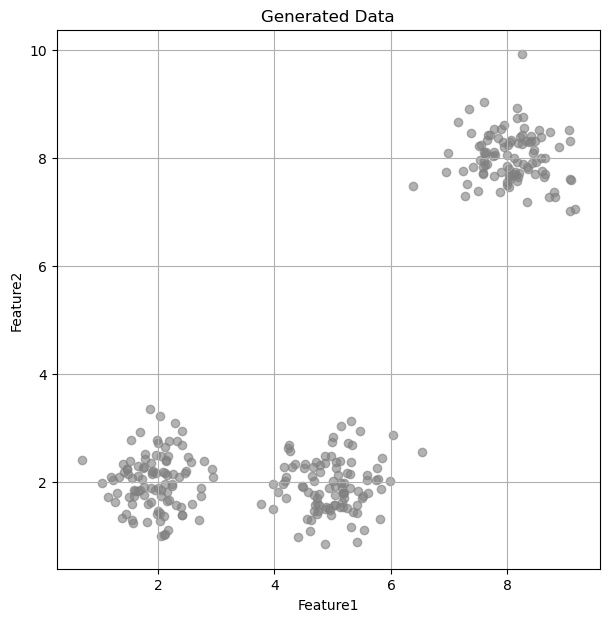

In [1]:
# 1. 라이브러리 임포트 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
# 2. 임의의 데이터 생성
np.random.seed(42)  # 재현성을 위한 시드 고정
data_1 = np.random.normal(loc = [2,2], scale = 0.5, size = (100,2)) # 첫번째 군집: 평균[2,2] 표준편차 0.5 샘플 100
data_2 = np.random.normal(loc = [8,8], scale = 0.5, size = (100,2)) # 두번째 군집: 평균[8,8] 표준편차 0.5 샘플 100
data_3 = np.random.normal(loc = [5,2], scale = 0.5, size = (100,2)) # 세번째 군집: 평균[5,2] 표준편차 0.5 샘플 100 
## 하나로 합치기
data = np.vstack([data_1, data_2, data_3])
## 데이터 시각화
plt.figure(figsize = (7,7))
plt.scatter(data[:,0], data[:,1], color = 'gray', alpha = 0.6)
plt.title('Generated Data')
plt.xlabel('Feature1')
plt.ylabel('Feature2')
plt.grid(True)
plt.show()

In [8]:
# 3. K-Means 모델 생성 및 학습
## 모델 생성 
kmeans = KMeans(n_clusters = 3, random_state = 42) # 3개의 군집으로 데이터 분류
## 데이터 학습
kmeans.fit(data) 
## 군집화 결과
labels = kmeans.labels_ # 각 데이터 포인트가 할당된 군집 번호, 데이터 크기와 동일한 배열로 반환
## 군집 중심점
centroids = kmeans.cluster_centers_ # 각 군집의 중심점 좌표, 군집 개수와 동일한 크기 배열로 반환
## 각 데이터 포인트의 군집 할당 결과 확인
labels


C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], d

In [9]:
centroids

array([[8.06412436, 8.02174382],
       [4.97748131, 1.93686366],
       [1.94221787, 2.01701116]])

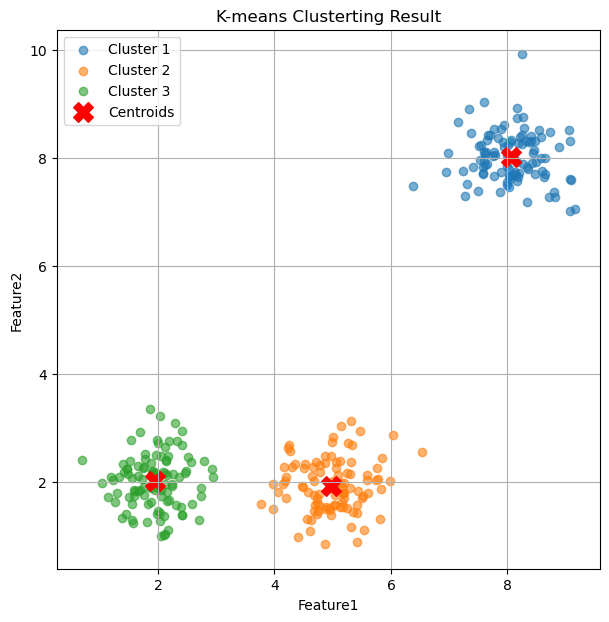

In [11]:
# 4. 군집 시각화
plt.figure(figsize = (7,7))
for cluster in np.unique(labels):
    plt.scatter(
        data[labels == cluster, 0], # 군집에 속환 데이터의 x축 값
        data[labels == cluster, 1], # 군집에 속한 데이터이 y축 값
        label = f'Cluster {cluster+1}', # 군집 번호
        alpha = 0.6
    )
## 중심점 시각화
plt.scatter(centroids[:,0], centroids[:,1], c='red', marker= 'X', s = 200, label = 'Centroids')
plt.title('K-means Clusterting Result')
plt.xlabel('Feature1')
plt.ylabel('Feature2')
plt.legend()
plt.grid(True)
plt.show()